# Interpretability Assessment of Latent Features learned on a single cell reference dataset and applied to a spatial transcriptomics dataset of different Embedding Methods

## Module Imports

In [ ]:
import itertools
from dataclasses import dataclass
from typing import Callable, Any, Sequence
import pickle
import mlflow
import scanpy as sc
import nico2_lib as n2l
import matplotlib.pyplot as plt
import numpy as np
from numpy import number
from numpy.typing import NDArray
import polars as pl
import seaborn as sns
from sklearn.neighbors import kneighbors_graph
from experiment import (
    DatasetDimension,
    CelltypeDimension,
    ExperimentResult,
    ModelDimension,
    ResultRecord,
    SampleDimension,
)

In [2]:
benchmark_experiment = mlflow.get_experiment_by_name("Default")
runs = mlflow.search_runs(experiment_ids=[benchmark_experiment.experiment_id])
last_run_id = runs.sort_values("start_time", ascending=False)["run_id"].iloc[0]

2026/02/23 09:57:30 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/23 09:57:30 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/23 09:57:30 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/23 09:57:30 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/23 09:57:30 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/23 09:57:30 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/23 09:57:31 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/23 09:57:31 INFO alembic.runtime.migration: Will assume non-transactional DDL.


In [3]:
artifact_path = mlflow.artifacts.download_artifacts(
    run_id=last_run_id, artifact_path="results.pkl"
)
with open(artifact_path, "rb") as f:
    results = pickle.load(f)

## Helpers

In [ ]:
NumericArray = NDArray[number]
MetricResult = list[dict[str, Any]]
MetricResultFn = Callable[[ResultRecord], MetricResult]


def construct_result_table(
    results: ExperimentResult,
    extract_results_fn: MetricResultFn,
) -> pl.DataFrame:

    rows: MetricResult = []

    for result in results.results:
        dataset = results.datasets[result.dataset_id]
        celltype = results.celltypes[result.celltype_id]
        sample = results.samples[result.sample_id]
        model = results.models[result.model_id]
        extracted_results = extract_results_fn(result)

        for extracted_result in extracted_results:
            rows.append(
                {
                    **extracted_result,
                    "dataset_name": dataset.dataset_name,
                    "celltype": celltype.celltype,
                    "sample_id": sample.sample_id,
                    "model_name": model.model_name,
                }
            )

    return pl.DataFrame(rows)

In [ ]:
def constant_corr(n: int, rho: float):
    corr = np.full((n, n), rho)
    np.fill_diagonal(corr, 1)
    return corr


corr = constant_corr(3, 0.8)


def generate_correlated_latent_embedding(
    n_features: int,
    strength: float,
    n_samples: int,
    rng: np.random.Generator | None = None,
) -> NumericArray:
    rng = rng or np.random.default_rng()
    cov = constant_corr(n_features, strength)
    return rng.multivariate_normal(mean=np.zeros(n_features), cov=cov, size=n_samples)


### Embedding Autocorrelation (Feature<->Feature)

In [ ]:
def _create_avg_pairwise_metric_fn(
    metric_fn: Callable[[NumericArray, NumericArray], float],
) -> Callable[[NumericArray], float]:
    """Returns a function that computes the average pairwise metric between feature columns.

    The returned function applies ``metric_fn`` to all unique pairs of columns
    in a 2D array of shape (n_samples, n_features) and returns the mean result.

    Args:
        metric_fn: Function that takes two 1D arrays and returns a float.

    Returns:
        Function that takes a 2D array and returns the average pairwise metric
        across all column pairs."""

    def pairwise_metric_fn(
        features: NumericArray,
    ) -> float:
        return np.array(
            [metric_fn(a, b) for a, b in itertools.combinations(features.T, 2)]
        ).mean()

    return pairwise_metric_fn


def build_autocorrelation_metric_registry():
    return {
        "pearsonr": _create_avg_pairwise_metric_fn(n2l.mt.pearson_metric),
        "spearmanr": _create_avg_pairwise_metric_fn(n2l.mt.spearman_metric),
        "cosine_similarity": _create_avg_pairwise_metric_fn(
            n2l.mt.cosine_similarity_metric
        ),
    }


def make_autocorrelation_metric_evaluator(
    metric_registry: dict[str, Callable[[NDArray[number]], float]],
) -> MetricResultFn:
    def evaluate_autocorrelation_metrics(
        result: ResultRecord,
    ) -> MetricResult:
        return [
            {
                "metric_name": metric_name,
                "global_model_result": metric_fn(result.global_model_embedding),
                "celltype_model_result": metric_fn(result.celltype_model_embedding),
            }
            for metric_name, metric_fn in metric_registry.items()
        ]

    return evaluate_autocorrelation_metrics

In [483]:
def plot_embeddings_with_metrics(
    n_features: int,
    strengths: Sequence[float],
    n_samples: int,
    metrics_registry: dict[str, Callable[[NumericArray], float]],
    rng: np.random.Generator | None = None,
):
    rng = rng or np.random.default_rng()

    for strength in strengths:
        embedding = generate_correlated_latent_embedding(
            n_features, strength, n_samples, rng
        )
        df = pl.DataFrame(embedding)

        metrics_results = {name: fn(embedding) for name, fn in metrics_registry.items()}
        metrics_text = "\n".join([f"{k}: {v:.2f}" for k, v in metrics_results.items()])

        g = sns.PairGrid(df)
        g.map(sns.scatterplot, s=15, alpha=0.6)

        ax = g.axes[0, -1]
        ax.text(
            1.05,
            0.5,
            metrics_text,
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment="center",
            bbox=dict(boxstyle="round,pad=0.3", alpha=0.2),
        )

        g.fig.suptitle(f"Correlation Strength = {strength}", fontsize=14, y=1.02)
        plt.show()

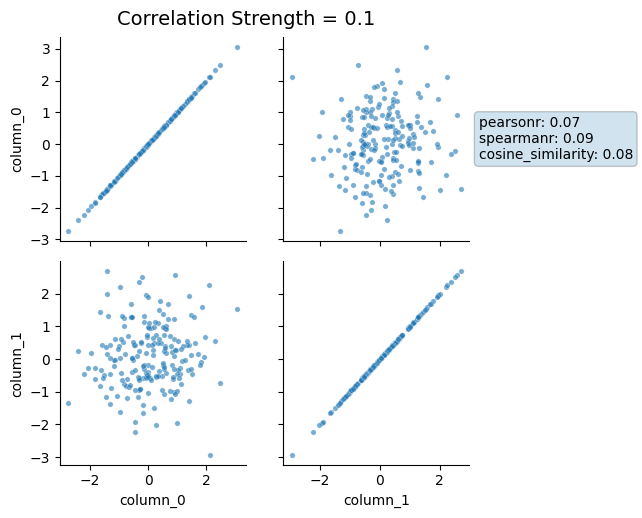

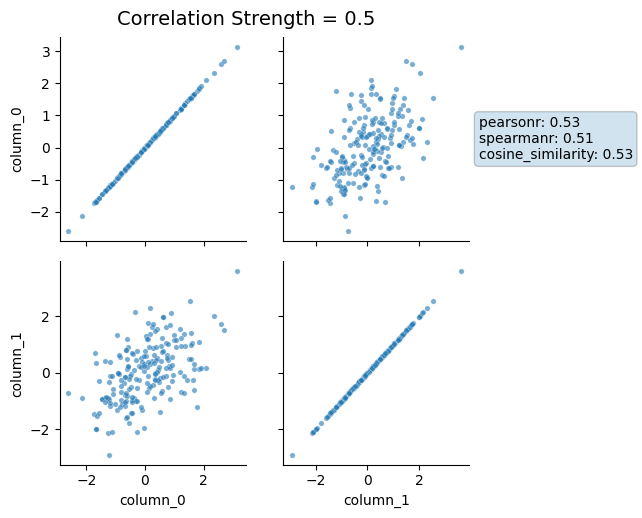

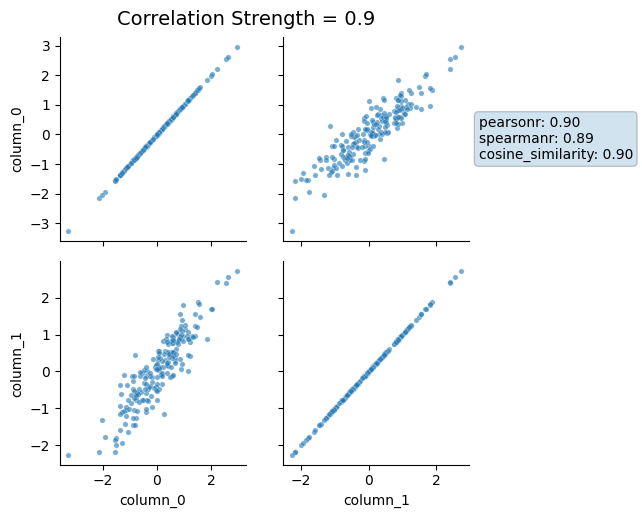

In [484]:
plot_embeddings_with_metrics(
    2,
    [0.1, 0.5, 0.9],
    200,
    build_autocorrelation_metric_registry(),
    np.random.default_rng(0),
)

In [228]:
autocorrelation_df = construct_result_table(
    results,
    extract_results_fn=make_autocorrelation_metric_evaluator(
        build_autocorrelation_metric_registry()
    ),
).unpivot(
    index=["metric_name", "dataset_name", "celltype", "sample_id", "model_name"],
    variable_name="model_prediction_scope",
    value_name="autocorrelation_score",
)
autocorrelation_df

metric_name,dataset_name,celltype,sample_id,model_name,model_prediction_scope,autocorrelation_score
str,str,str,i64,str,str,f64
"""pearsonr""","""small_mouse_intestine_spatial""","""BZE""",0,"""NMF_3""","""global_model_result""",0.258978
"""spearmanr""","""small_mouse_intestine_spatial""","""BZE""",0,"""NMF_3""","""global_model_result""",0.503496
"""cosine_similarity""","""small_mouse_intestine_spatial""","""BZE""",0,"""NMF_3""","""global_model_result""",0.470748
"""pearsonr""","""small_mouse_intestine_spatial""","""Blood vasc.""",0,"""NMF_3""","""global_model_result""",0.174806
"""spearmanr""","""small_mouse_intestine_spatial""","""Blood vasc.""",0,"""NMF_3""","""global_model_result""",0.528333
…,…,…,…,…,…,…
"""spearmanr""","""small_mouse_intestine_spatial""","""cDC/monocyte""",9,"""NMF_8""","""celltype_model_result""",0.031895
"""cosine_similarity""","""small_mouse_intestine_spatial""","""cDC/monocyte""",9,"""NMF_8""","""celltype_model_result""",0.321024
"""pearsonr""","""small_mouse_intestine_spatial""","""neurons/enteroendocrine""",9,"""NMF_8""","""celltype_model_result""",0.030652


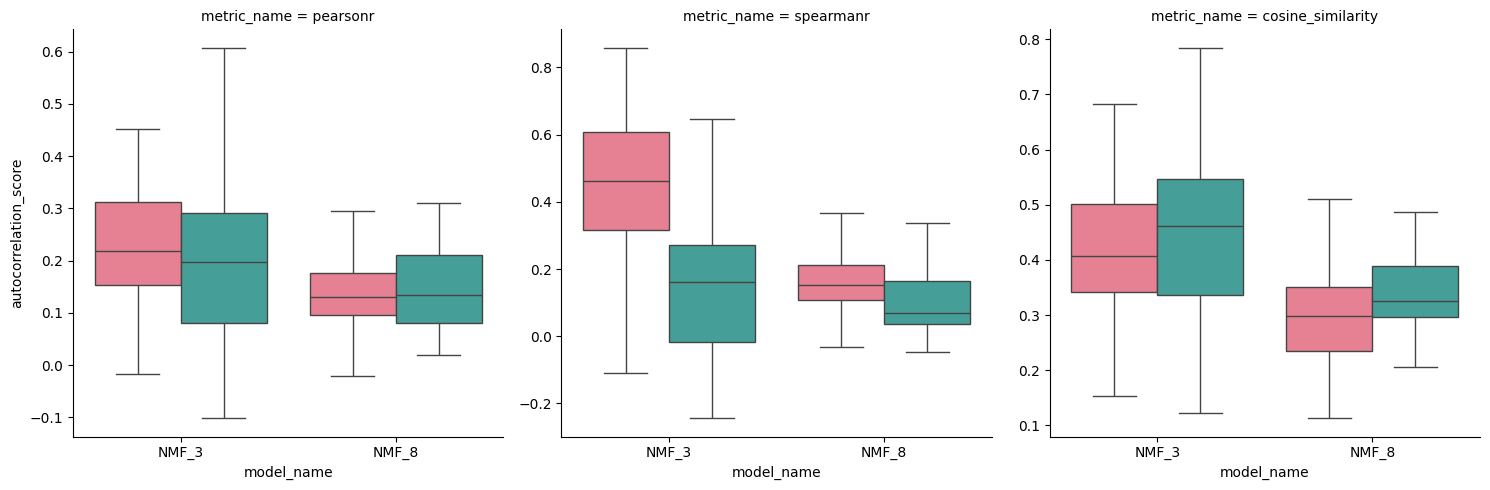

In [503]:
for (dataset_name,), autocorrelation_dataset_df in autocorrelation_df.partition_by(
    "dataset_name", as_dict=True
).items():
    g = sns.FacetGrid(
        autocorrelation_dataset_df,
        col="metric_name",
        sharey=False,
        height=5,
    )
    g.map_dataframe(
        sns.boxplot,
        x="model_name",
        y="autocorrelation_score",
        hue="model_prediction_scope",
        showfliers=False,
        palette=sns.color_palette("husl", 2),
    )
    plt.show()

### Global Spatial Autocorrelation

In [ ]:
import scipy.sparse.csgraph as csgraph


def _create_avg_interpretability_metric_fn(
    metric_fn: Callable[[NumericArray, NumericArray], float],
) -> Callable[[NumericArray, NumericArray], float]:
    def avg_interpretabilty_metric_fn(adjacency: NumericArray, features: NumericArray):
        return float(
            np.array([metric_fn(adjacency, feature) for feature in features.T]).mean()
        )

    return avg_interpretabilty_metric_fn


@_create_avg_interpretability_metric_fn
def laplacian_smoothness(adjacency: NumericArray, feature: NumericArray) -> float:
    """x^T L x — lower means smoother / more structured"""
    L = csgraph.laplacian(adjacency, normed=False)
    return float(feature.T @ (L @ feature))


@_create_avg_interpretability_metric_fn
def normalized_laplacian_smoothness(
    adjacency: NumericArray, feature: NumericArray
) -> float:
    """Normalized smoothness (scale-invariant)"""
    L = csgraph.laplacian(adjacency, normed=True)
    return float(feature.T @ (L @ feature))


def build_interpretability_metric_registry() -> dict[
    str, Callable[[NumericArray, NumericArray], float]
]:
    return {
        "morans_i": _create_avg_interpretability_metric_fn(
            lambda adjacency, feature: sc.metrics.morans_i(adjacency, feature)
        ),
        "gearys_c": _create_avg_interpretability_metric_fn(
            lambda adjacency, feature: sc.metrics.gearys_c(adjacency, feature)
        ),
        "lap_smoothness": laplacian_smoothness,
        "lap_smoothness_norm": normalized_laplacian_smoothness,
    }

In [ ]:
@dataclass
class ExtendedCelltypeDimension:
    celltype: CelltypeDimension
    ajdacency_matrix: NDArray[number]


n_neighbours = 15
extended_celltypes = [
    ExtendedCelltypeDimension(
        celltype,
        kneighbors_graph(celltype.pca_embedding, n_neighbors=n_neighbours),
    )
    for celltype in results.celltypes
]

In [233]:
def make_interpretability_metric_evaluator(
    metric_registry: dict[str, Callable[[NDArray[number], NDArray[number]], float]],
    extended_celltypes: list[ExtendedCelltypeDimension],
) -> MetricResultFn:
    def evaluate_interpretability_metrics(result: ResultRecord) -> MetricResult:
        return [
            {
                "metric_name": metric_name,
                "global_model_results": metric_fn(
                    extended_celltypes[result.celltype_id].ajdacency_matrix,
                    result.global_model_embedding,
                ),
                "celltype_model_results": metric_fn(
                    extended_celltypes[result.celltype_id].ajdacency_matrix,
                    result.celltype_model_embedding,
                ),
            }
            for metric_name, metric_fn in metric_registry.items()
        ]

    return evaluate_interpretability_metrics

In [501]:
interpretability_df = construct_result_table(
    results,
    extract_results_fn=make_interpretability_metric_evaluator(
        metric_registry=build_interpretability_metric_registry(),
        extended_celltypes=extended_celltypes,
    ),
).unpivot(
    index=["metric_name", "dataset_name", "celltype", "sample_id", "model_name"],
    variable_name="model_prediction_scope",
    value_name="interpretability_score",
)
interpretability_df

metric_name,dataset_name,celltype,sample_id,model_name,model_prediction_scope,interpretability_score
str,str,str,i64,str,str,f64
"""morans_i""","""small_mouse_intestine_spatial""","""BZE""",0,"""NMF_3""","""global_model_results""",0.507461
"""gearys_c""","""small_mouse_intestine_spatial""","""BZE""",0,"""NMF_3""","""global_model_results""",0.426455
"""lap_smoothness""","""small_mouse_intestine_spatial""","""BZE""",0,"""NMF_3""","""global_model_results""",38.865981
"""lap_smoothness_norm""","""small_mouse_intestine_spatial""","""BZE""",0,"""NMF_3""","""global_model_results""",-17.12344
"""morans_i""","""small_mouse_intestine_spatial""","""Blood vasc.""",0,"""NMF_3""","""global_model_results""",0.26347
…,…,…,…,…,…,…
"""lap_smoothness_norm""","""small_mouse_intestine_spatial""","""cDC/monocyte""",9,"""NMF_8""","""celltype_model_results""",-1.137008
"""morans_i""","""small_mouse_intestine_spatial""","""neurons/enteroendocrine""",9,"""NMF_8""","""celltype_model_results""",-0.002341
"""gearys_c""","""small_mouse_intestine_spatial""","""neurons/enteroendocrine""",9,"""NMF_8""","""celltype_model_results""",0.768237


<Figure size 1920x1440 with 0 Axes>

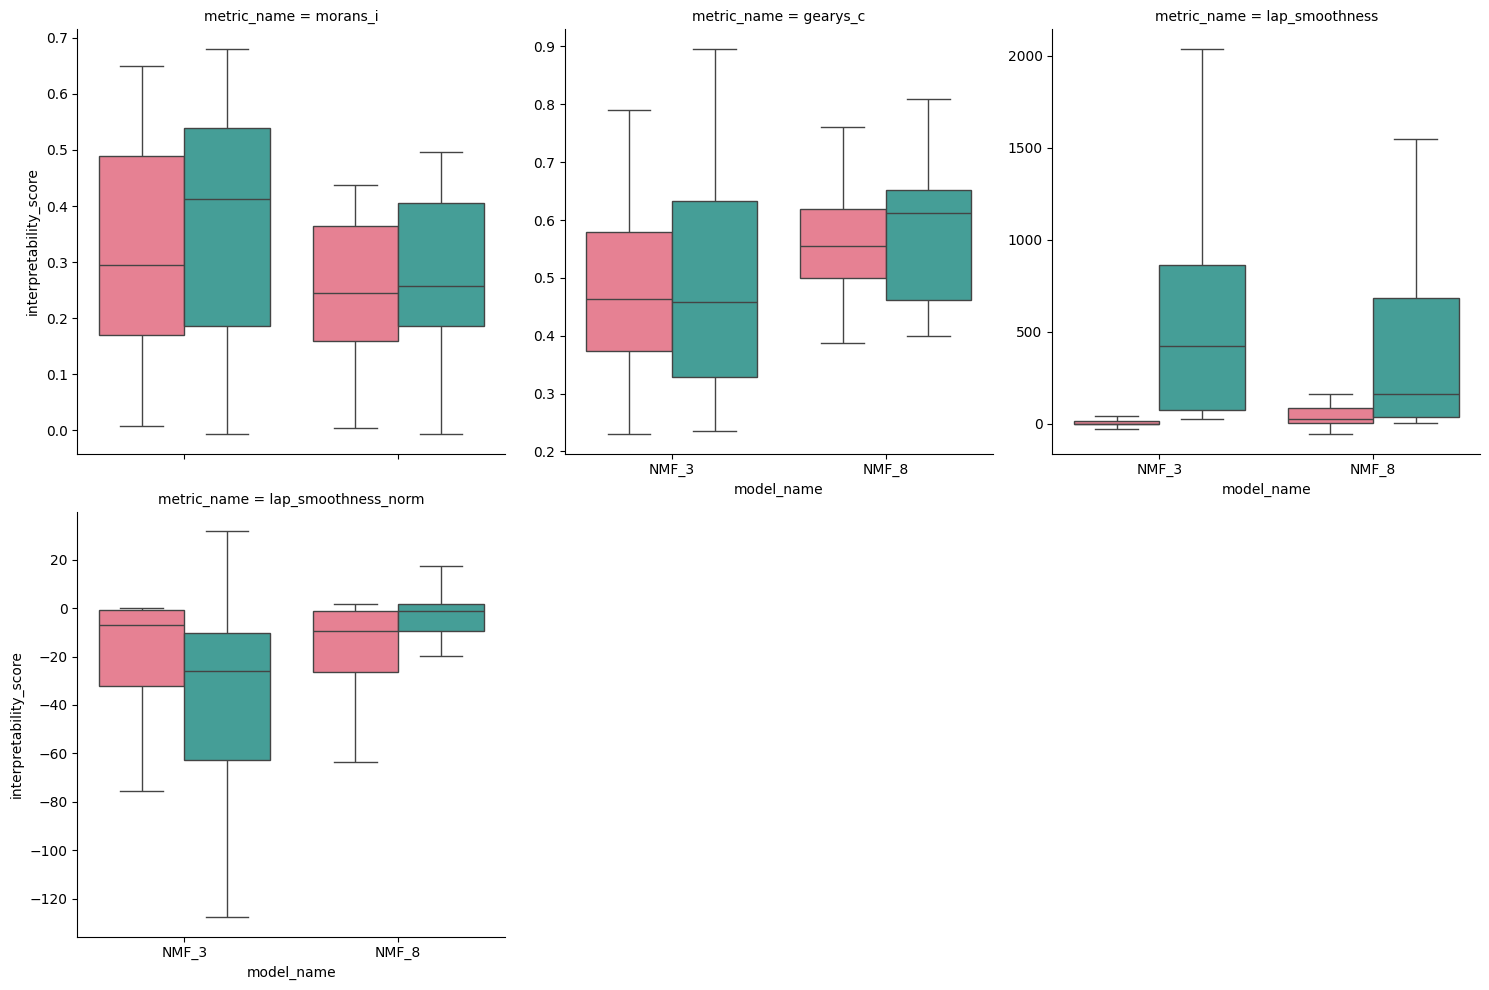

In [ ]:
for (dataset_name,), interpretability_dataset_df in interpretability_df.partition_by(
    "dataset_name", as_dict=True
).items():
    plt.figure(dpi=300)
    g = sns.FacetGrid(
        interpretability_dataset_df,
        col="metric_name",
        sharey=False,
        height=5,
        col_wrap=3,
    )
    g.map_dataframe(
        sns.boxplot,
        x="model_name",
        y="interpretability_score",
        hue="model_prediction_scope",
        showfliers=False,
        palette=sns.color_palette("husl", 2),
    )
    plt.show()